# LIBRARY

In [263]:
%pip install scikit-plot -q
%pip install scipy -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [264]:
import numpy as np
import scipy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall
from sklearn.tree._tree import TREE_LEAF
from sklearn.tree import plot_tree, DecisionTreeRegressor
import matplotlib.pyplot as plt

In [265]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error, 
    r2_score
)

# IMPORT CONTROL DATA SET 

In [266]:
file_path = "../1.DATASET/CMI_V2_CONTROL.csv"
df=pd.read_csv(file_path)
df

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,1,9,0,NaN,14.035590,48.00,46.0,936.656,70.0,NaN,...,1.0,15.4107,27.0552,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
1,3,9,0,71.0,18.292347,56.00,81.6,1131.430,97.0,6.0,...,2.0,26.4798,45.9966,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
2,5,13,1,50.0,22.279952,59.50,112.2,1330.970,73.0,5.0,...,2.0,35.3804,63.1265,56.0,0.0,1.0,74.000000,18.000000,17.200000,10.500000
3,6,10,0,NaN,19.660760,55.00,84.6,1135.860,83.0,NaN,...,2.0,26.1957,47.2211,40.0,3.0,0.0,136.333333,11.000000,16.840263,11.000000
4,7,10,1,65.0,16.861286,59.25,84.2,1180.040,90.0,5.0,...,2.0,28.7680,50.4767,55.0,2.0,0.0,86.000000,14.662915,11.850000,7.682875
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852,3952,15,0,40.0,26.364710,70.50,186.4,1719.310,74.0,5.0,...,3.0,54.2027,91.4887,90.0,3.0,1.0,117.333333,23.714789,26.417470,8.527654
1853,3953,8,0,65.0,17.139810,52.50,67.2,1035.270,65.0,NaN,...,1.0,20.2645,36.7181,58.0,2.0,0.0,77.333333,10.568299,18.526452,9.000000
1854,3954,7,1,NaN,13.927006,48.50,46.6,966.287,75.0,5.0,...,1.0,18.0937,30.0453,67.0,0.0,1.0,78.333333,9.540221,18.909726,8.750000
1855,3955,13,0,60.0,16.362460,59.50,82.4,1206.880,70.0,NaN,...,1.0,29.7790,52.8320,50.0,1.0,1.0,82.000000,26.000000,18.950000,8.500000


In [267]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1857 entries, 0 to 1856
Data columns (total 32 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      1857 non-null   int64  
 1   Basic_Demos-Age                         1857 non-null   int64  
 2   Basic_Demos-Sex                         1857 non-null   int64  
 3   CGAS-CGAS_Score                         1679 non-null   float64
 4   Physical-BMI                            1857 non-null   float64
 5   Physical-Height                         1857 non-null   float64
 6   Physical-Weight                         1857 non-null   float64
 7   BIA-BIA_BMR                             1856 non-null   float64
 8   Physical-HeartRate                      1853 non-null   float64
 9   Fitness_Endurance-Max_Stage             1206 non-null   float64
 10  FGC-FGC_TL                              1708 non-null   floa

# Data Cleaning

## Removing useless variables

In [268]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)

In [269]:
df.head()

,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,BIA-BIA_BMR,Physical-HeartRate,Fitness_Endurance-Max_Stage,FGC-FGC_TL,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,9,0,NaN,14.035590,48.00,46.0,936.656,70.0,NaN,3.0,...,1.0,15.4107,27.0552,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
1,9,0,71.0,18.292347,56.00,81.6,1131.430,97.0,6.0,7.0,...,2.0,26.4798,45.9966,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
2,13,1,50.0,22.279952,59.50,112.2,1330.970,73.0,5.0,8.0,...,2.0,35.3804,63.1265,56.0,0.0,1.0,74.000000,18.000000,17.200000,10.500000
3,10,0,NaN,19.660760,55.00,84.6,1135.860,83.0,NaN,11.0,...,2.0,26.1957,47.2211,40.0,3.0,0.0,136.333333,11.000000,16.840263,11.000000
4,10,1,65.0,16.861286,59.25,84.2,1180.040,90.0,5.0,4.0,...,2.0,28.7680,50.4767,55.0,2.0,0.0,86.000000,14.662915,11.850000,7.682875


# TARGET VARIABLES

## TARGET VARIABLE Physical-Height

In [270]:
df_height = df[[ 'Physical-BMI','Physical-Height', 'Physical-Weight']].copy()


In [271]:
df_height.isnull().sum()

Physical-BMI       0
Physical-Height    0
Physical-Weight    0
dtype: int64

In [272]:
df_height[df_height['Physical-Height']==0]

,Physical-BMI,Physical-Height,Physical-Weight


### Partitioning

In [273]:
attributes = [col for col in df_height.columns if col != 'Physical-Height']
X = df_height[attributes].values
y = np.array(df_height['Physical-Height'])

In [274]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [275]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 2) (465, 2) (1392,) (465,)


In [276]:
df_height.shape

(1857, 3)

### Randomized Search

In [277]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [278]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_height = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_height = random_search.best_estimator_

In [279]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 5, 'max_depth': 30, 'criterion': 'absolute_error'} -1.4490786593306


In [280]:
dt_reg_height = random_search.best_estimator_
dt_reg_height.fit(X_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=30,
                      min_samples_leaf=5, min_samples_split=0.002)

In [281]:
y_pred = dt_reg_height.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 1.1361
MAE  : 0.7180
MSE  : 1.2908
R²   : 0.9754


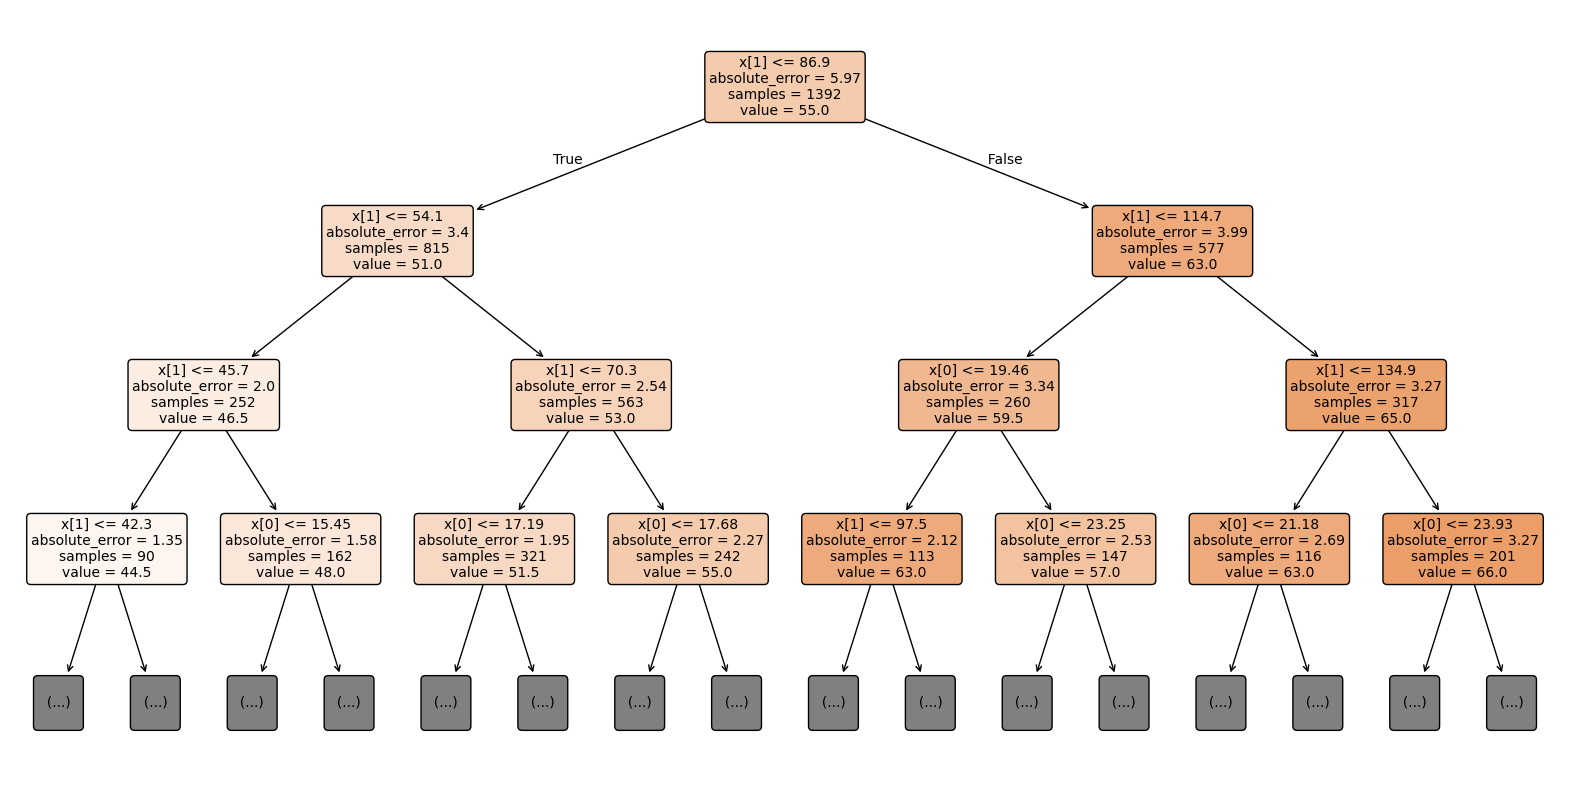

In [282]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_height,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  24 | 77.5000 |   69.2500 | 8.2500
 311 | 49.0000 |   56.5000 | 7.5000
  77 | 41.5000 |   48.0000 | 6.5000
 130 | 74.5000 |   69.2500 | 5.2500
 372 | 74.5000 |   69.2500 | 5.2500
 463 | 70.5000 |   66.5500 | 3.9500
  99 | 64.0000 |   61.0000 | 3.0000
 210 | 50.0000 |   53.0000 | 3.0000
 158 | 53.0000 |   55.6250 | 2.6250
 415 | 70.5000 |   68.0000 | 2.5000


C:\Users\paula\AppData\Local\Temp\ipykernel_24812\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


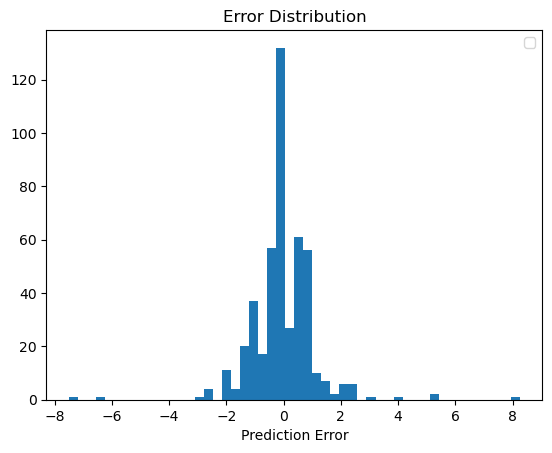

In [283]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [284]:
zipped = zip(attributes, dt_reg_height.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Physical-Weight 0.7672299103049788
Physical-BMI 0.2327700896950211


## TARGET VARIABLE BIA-BIA_TBW

In [285]:
df_BIA_TBW = df[['BIA-BIA_ECW', 'BIA-BIA_ICW','BIA-BIA_TBW']].copy()



In [286]:
#df_BIA_TBW=df_BIA_TBW.dropna(subset=['BIA-BIA_FFMI'])

In [287]:
df_BIA_TBW.isnull().sum()

BIA-BIA_ECW    0
BIA-BIA_ICW    0
BIA-BIA_TBW    0
dtype: int64

In [288]:
df_BIA_TBW[df_BIA_TBW['BIA-BIA_TBW']==0]

,BIA-BIA_ECW,BIA-BIA_ICW,BIA-BIA_TBW


### Partitioning

In [289]:
attributes = [col for col in df_BIA_TBW.columns if col != 'BIA-BIA_TBW']
X = df_BIA_TBW[attributes].values
y = np.array(df_BIA_TBW['BIA-BIA_TBW'])

In [290]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [291]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 2) (465, 2) (1392,) (465,)


In [292]:
df_BIA_TBW.shape

(1857, 3)

### Randomized Search

In [293]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [294]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_TBW = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_TBW = random_search.best_estimator_

In [295]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.001, 'min_samples_leaf': 5, 'max_depth': 36, 'criterion': 'friedman_mse'} -1.5664493740721026


In [296]:
dt_reg_TBW = random_search.best_estimator_
dt_reg_TBW.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=36,
                      min_samples_leaf=5, min_samples_split=0.001)

In [297]:
y_pred = dt_reg_TBW.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 0.9783
MAE  : 0.6263
MSE  : 0.9570
R²   : 0.9972


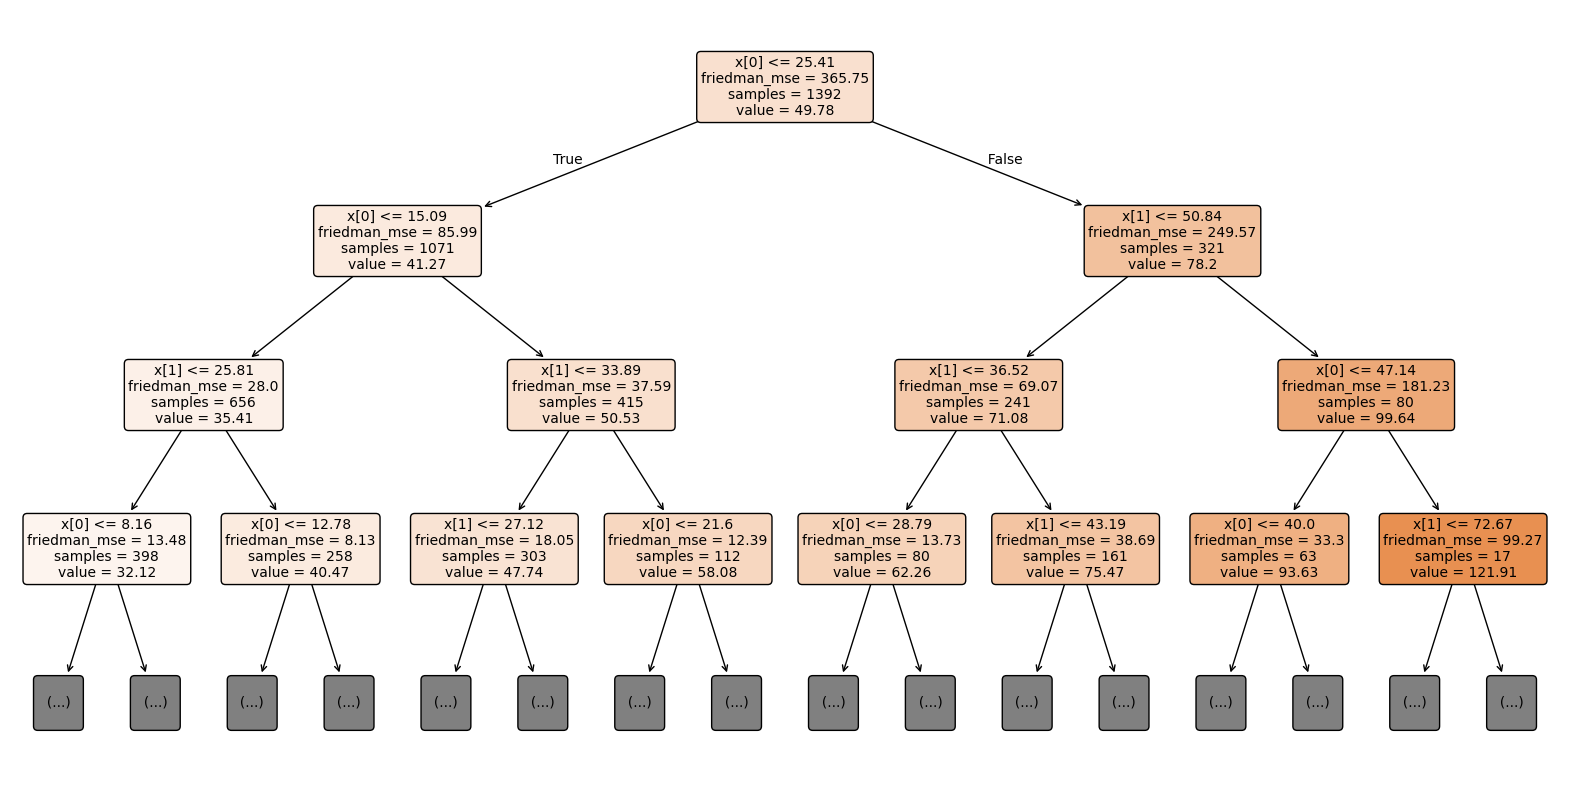

In [298]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_TBW,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  24 | 125.9560 |  120.2422 | 5.7138
 405 | 22.8800 |   28.0992 | 5.2192
 196 | 81.5263 |   86.3486 | 4.8223
 186 | 60.2056 |   56.1244 | 4.0812
 121 | 107.0920 |  103.3416 | 3.7504
 145 | 83.5786 |   80.0303 | 3.5483
 162 | 74.0409 |   77.4125 | 3.3716
  93 | 123.5600 |  120.2422 | 3.3178
 366 | 132.1710 |  135.4846 | 3.3136
 427 | 74.5008 |   71.5858 | 2.9150


C:\Users\paula\AppData\Local\Temp\ipykernel_24812\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


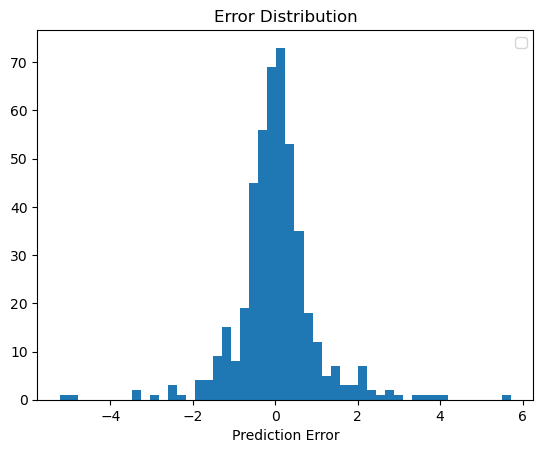

In [299]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [300]:
zipped = zip(attributes, dt_reg_TBW.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_ECW 0.8258427688196224
BIA-BIA_ICW 0.1741572311803776


## TARGET VARIABLE BIA-BIA_Fat

In [301]:
df_BIA_Fat = df[['Physical-Weight', 
                'Physical-Height','BIA-BIA_FMI',
                'BIA-BIA_Fat'                          
]].copy()



In [302]:
#df_BIA_Fat=df_BIA_Fat.dropna(subset=['BIA-BIA_FFMI','Physical-HeartRate'])

In [303]:
df_BIA_Fat.isnull().sum()

Physical-Weight    0
Physical-Height    0
BIA-BIA_FMI        0
BIA-BIA_Fat        0
dtype: int64

### Partitioning

In [304]:
attributes = [col for col in df_BIA_Fat.columns if col != 'BIA-BIA_Fat']
X = df_BIA_Fat[attributes].values
y = np.array(df_BIA_Fat['BIA-BIA_Fat'])

In [305]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [306]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 3) (465, 3) (1392,) (465,)


In [307]:
df_BIA_Fat.shape

(1857, 4)

### Randomized Search

In [308]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [309]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_FAT = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_FAT = random_search.best_estimator_

In [310]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.001, 'min_samples_leaf': 5, 'max_depth': 16, 'criterion': 'absolute_error'} -8.5157971591163


In [311]:
dt_reg_FAT = random_search.best_estimator_
dt_reg_FAT.fit(X_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=16,
                      min_samples_leaf=5, min_samples_split=0.001)

In [312]:
y_pred = dt_reg_FAT.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 2.1452
MAE  : 1.1915
MSE  : 4.6020
R²   : 0.9866


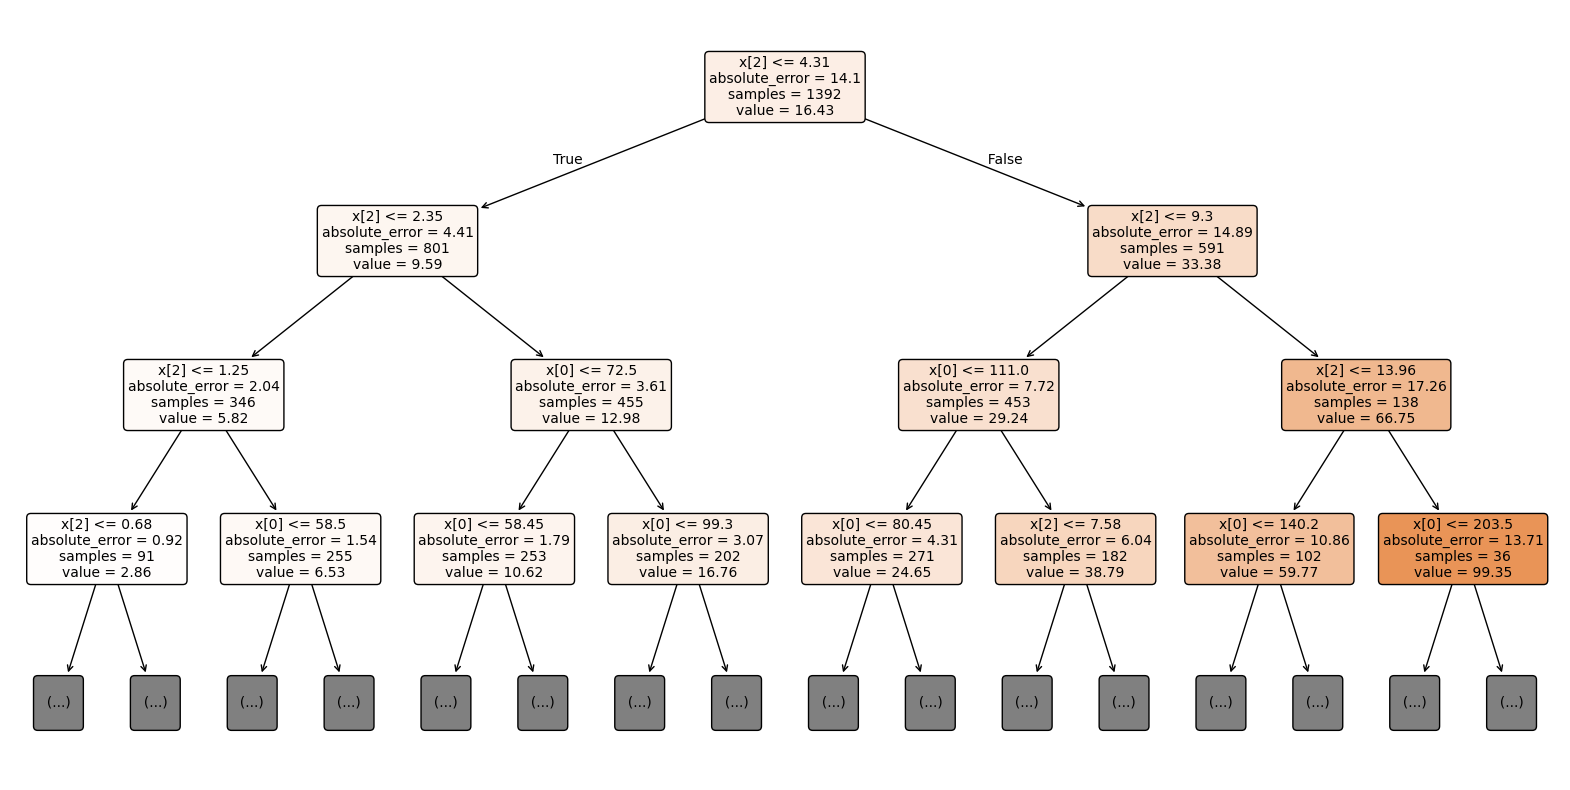

In [313]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_FAT,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 366 | 126.0100 |  105.8120 | 20.1980
 311 | 58.6013 |   75.4429 | 16.8416
 145 | 108.8070 |  116.9160 | 8.1090
 127 | 81.4070 |   88.6792 | 7.2722
 130 | 57.1916 |   50.0139 | 7.1777
 393 | 56.1160 |   49.2732 | 6.8428
  98 | 42.4451 |   35.7149 | 6.7302
   9 | 71.3179 |   64.5942 | 6.7237
  18 | 39.2171 |   45.5311 | 6.3139
 293 | 75.8225 |   69.7108 | 6.1117


C:\Users\paula\AppData\Local\Temp\ipykernel_24812\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


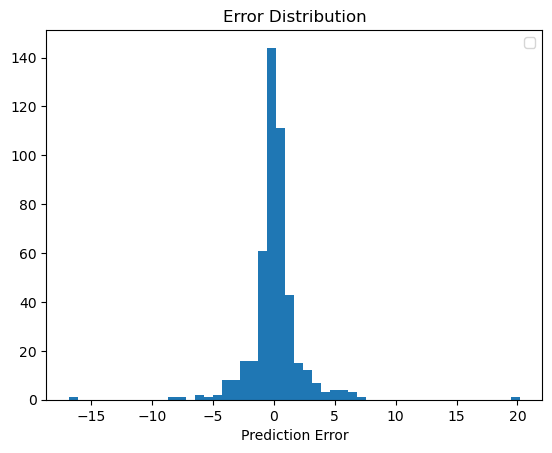

In [314]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [315]:
zipped = zip(attributes, dt_reg_FAT.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_FMI 0.7618840933852153
Physical-Weight 0.21623904102577876
Physical-Height 0.021876865589005985


## TARGET VARIABLE BIA-BIA_DEE

In [329]:
df_BIA_DEE = df[[
    'BIA-BIA_DEE','BIA-BIA_BMR','Basic_Demos-Sex','BIA-BIA_TBW']].copy()

  #'Basic_Demos-Age', 'Physical-Weight', 
   #             'Physical-Height',
   #             'BIA-BIA_FMI','BIA-BIA_FFMI','Physical-MAP_CAL',
   #             'Physical-HeartRate',,'BIA-BIA_Fat',

In [333]:
df_BIA_DEE=df_BIA_DEE.dropna(subset=['BIA-BIA_DEE','BIA-BIA_BMR'])

In [334]:
df_BIA_DEE.isnull().sum()

BIA-BIA_DEE        0
BIA-BIA_BMR        0
Basic_Demos-Sex    0
BIA-BIA_TBW        0
dtype: int64

### Partitioning

In [335]:
attributes = [col for col in df_BIA_DEE.columns if col != 'BIA-BIA_DEE']
X = df_BIA_DEE[attributes].values
y = np.array(df_BIA_DEE['BIA-BIA_DEE'])

In [336]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [321]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1389, 11) (463, 11) (1389,) (463,)


In [337]:
df_BIA_DEE.shape

(1856, 4)

### Randomized Search

In [ ]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [338]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_DEE = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_DEE = random_search.best_estimator_

In [339]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.01, 'min_samples_leaf': 30, 'max_depth': 25, 'criterion': 'absolute_error'} -93377.07924982878


In [340]:
dt_reg_DEE = random_search.best_estimator_
dt_reg_DEE.fit(X_train, y_train)

DecisionTreeRegressor(criterion='absolute_error', max_depth=25,
                      min_samples_leaf=30, min_samples_split=0.01)

In [341]:
y_pred = dt_reg_DEE.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 308.7041
MAE  : 199.0780
MSE  : 95298.2126
R²   : 0.6530


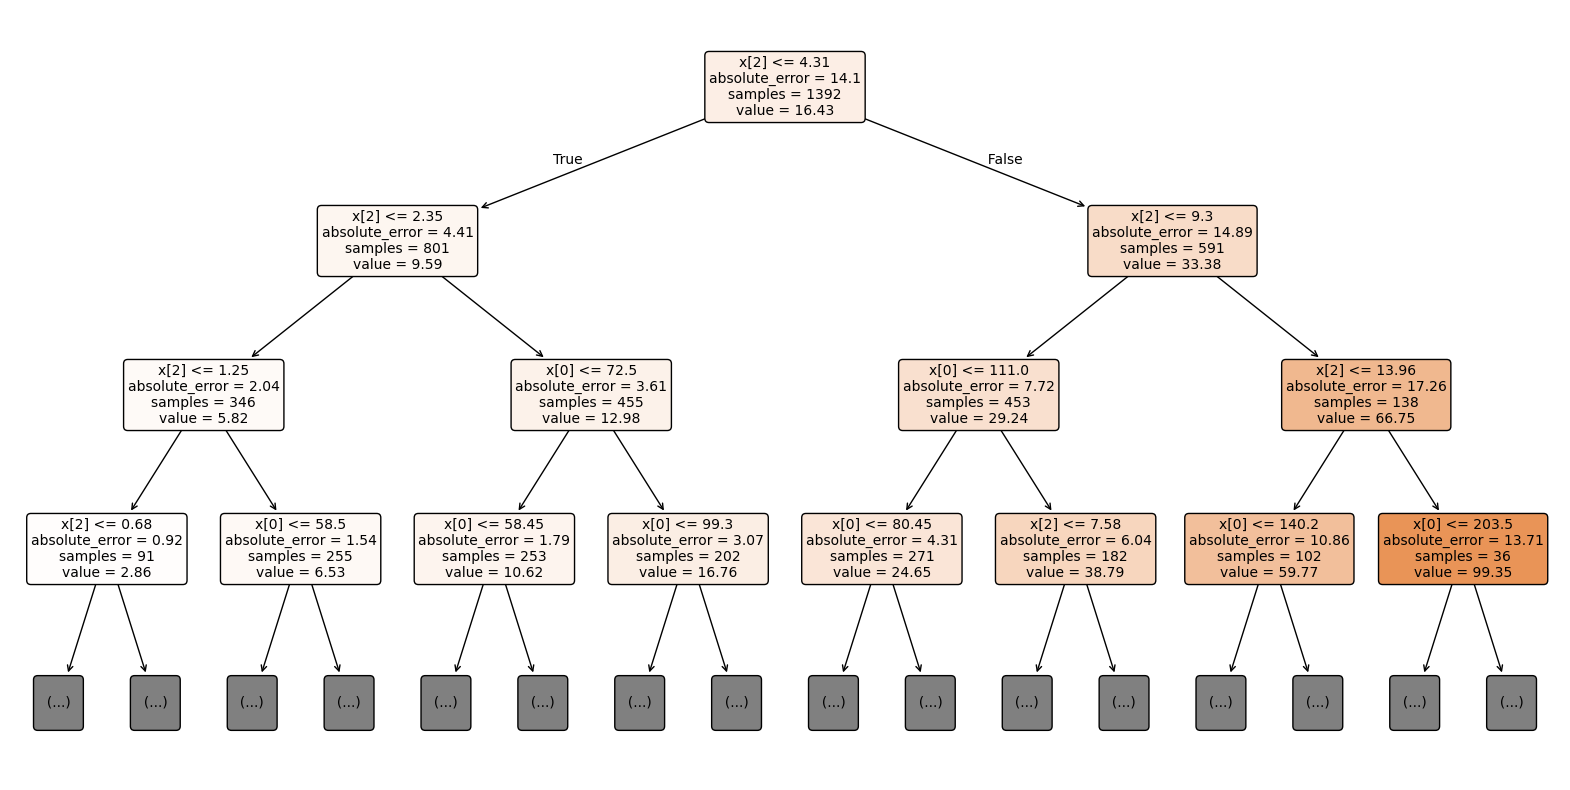

In [ ]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_DEE,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
 366 | 126.0100 |  105.8120 | 20.1980
 311 | 58.6013 |   75.4429 | 16.8416
 145 | 108.8070 |  116.9160 | 8.1090
 127 | 81.4070 |   88.6792 | 7.2722
 130 | 57.1916 |   50.0139 | 7.1777
 393 | 56.1160 |   49.2732 | 6.8428
  98 | 42.4451 |   35.7149 | 6.7302
   9 | 71.3179 |   64.5942 | 6.7237
  18 | 39.2171 |   45.5311 | 6.3139
 293 | 75.8225 |   69.7108 | 6.1117


C:\Users\paula\AppData\Local\Temp\ipykernel_24812\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


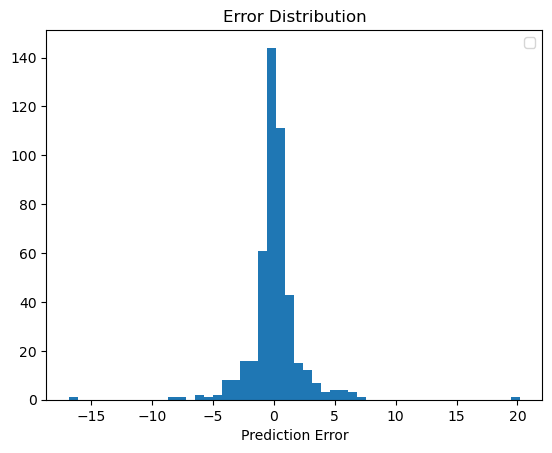

In [ ]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [328]:
zipped = zip(attributes, dt_reg_DEE.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

BIA-BIA_BMR 0.7548566847149618
BIA-BIA_TBW 0.09611541229258867
Basic_Demos-Sex 0.07161829298839098
Physical-HeartRate 0.023405046276513655
BIA-BIA_Fat 0.020811726453242592
Physical-Height 0.0194699227968685
Physical-MAP_CAL 0.004929785542842755
BIA-BIA_FMI 0.00437016670942459
BIA-BIA_FFMI 0.0027016034601410866
Basic_Demos-Age 0.0010321540369329415
Physical-Weight 0.0006892047280923432


## TARGET VARIABLE Physical-HeartRate

In [137]:
df_HeartRate = df[['Basic_Demos-Age','Basic_Demos-Sex', 'Physical-Weight',
                   'Physical-Height','Physical-MAP_CAL']].copy()

##'BIA-BIA_FMI','BIA-BIA_FFMI'


In [123]:
df_HeartRate=df_HeartRate.dropna(subset=['BIA-BIA_FFMI'])

In [138]:
df_HeartRate.isnull().sum()

Basic_Demos-Age     0
Basic_Demos-Sex     0
Physical-Weight     0
Physical-Height     0
Physical-MAP_CAL    0
dtype: int64

### Partitioning

In [139]:
attributes = [col for col in df_HeartRate.columns if col != 'Physical-MAP_CAL']
X = df_HeartRate[attributes].values
y = np.array(df_HeartRate['Physical-MAP_CAL'])

In [140]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)


In [141]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1392, 4) (465, 4) (1392,) (465,)


In [142]:
df_HeartRate.shape

(1857, 5)

### Randomized Search

In [ ]:
# options for scoring
#scoring='neg_mean_squared_error'      # most common, minimizes large errors
#scoring='neg_mean_absolute_error'     # more robust to outliers
#scoring='neg_root_mean_squared_error' # directly in target units
#scoring='r2'                          # maximizes explained variance

In [143]:
param_list = {
    'max_depth': [None] + list(np.arange(2, 50)),
    'min_samples_split': [0.001, 0.002, 0.01, 0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20, 30, 50, 100, 150],
    'criterion': ['squared_error', 'absolute_error', 'friedman_mse']  
}

dt_reg_HeartRate = DecisionTreeRegressor()  

random_search = RandomizedSearchCV(
    DecisionTreeRegressor(),    
    param_distributions=param_list,
    cv=KFold(n_splits=5, shuffle=True, random_state=0), 
    scoring='neg_mean_squared_error' ,   
    n_jobs=-1,
    refit=True,
    n_iter=300,
)

random_search.fit(X_train, y_train)
dt_reg_HeartRate = random_search.best_estimator_

In [144]:
print(random_search.best_params_, random_search.best_score_)

{'min_samples_split': 0.002, 'min_samples_leaf': 10, 'max_depth': 2, 'criterion': 'friedman_mse'} -151.9660694098013


In [145]:
dt_reg_HeartRate = random_search.best_estimator_
dt_reg_HeartRate.fit(X_train, y_train)

DecisionTreeRegressor(criterion='friedman_mse', max_depth=2,
                      min_samples_leaf=10, min_samples_split=0.002)

In [146]:
y_pred = dt_reg_HeartRate.predict(X_test)

print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}") # Typical error
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.4f}")  #Average Error
print(f"MSE  : {mean_squared_error(y_test, y_pred):.4f}")  #Average Error
print(f"R²   : {r2_score(y_test, y_pred):.4f}") # variance in the target variable

RMSE : 12.8685
MAE  : 8.8009
MSE  : 165.5985
R²   : 0.0495


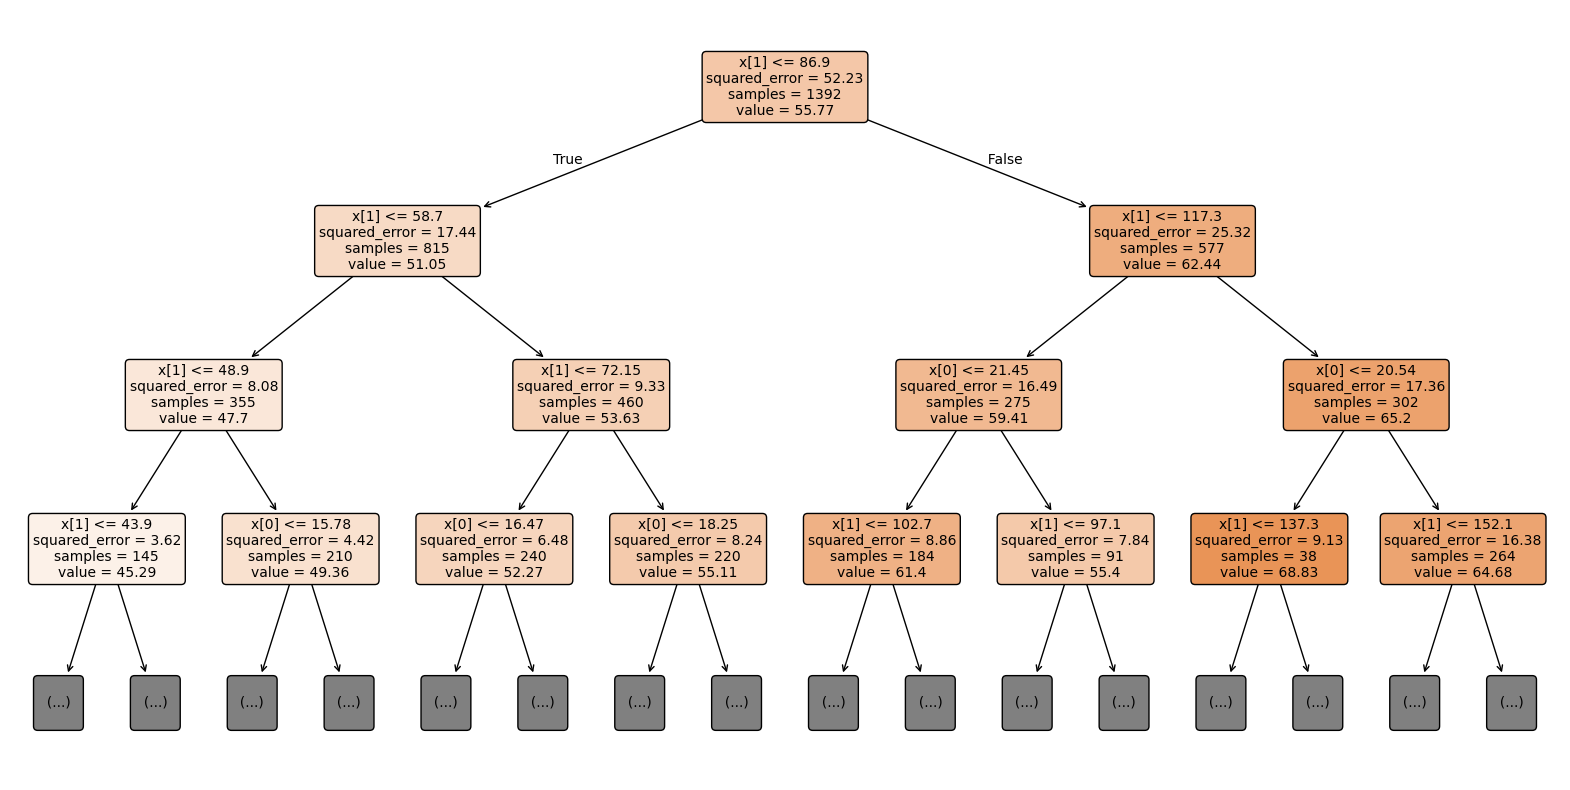

In [147]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_reg_height,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=2,
    max_depth = 3
)

plt.show()

Idx | Actual | Predicted | Error
----------------------------------------
  15 | 154.0000 |   83.0247 | 70.9753
 133 | 140.0000 |   79.3414 | 60.6586
  75 | 134.6667 |   87.0299 | 47.6368
 110 | 129.0000 |   82.0243 | 46.9757
  76 | 37.6667 |   82.0243 | 44.3576
 282 | 120.3333 |   79.3414 | 40.9919
 111 | 131.3333 |   92.4570 | 38.8764
 430 | 125.3333 |   87.0299 | 38.3035
 368 | 47.6667 |   84.7918 | 37.1252
 180 | 50.6667 |   87.0299 | 36.3632


C:\Users\paula\AppData\Local\Temp\ipykernel_24812\1016786874.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


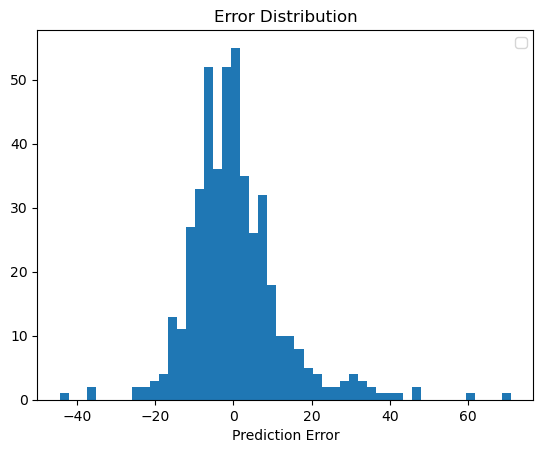

In [135]:
errors = np.abs(y_test - y_pred)

# Top 10 worst predictions
worst_indices = np.argsort(errors)[-10:][::-1]

print("Idx | Actual | Predicted | Error")
print("-" * 40)
for i in worst_indices:
    print(f"{i:4d} | {y_test[i]:7.4f} | {y_pred[i]:9.4f} | {errors[i]:.4f}")

# Error distribution plot
plt.hist(y_test - y_pred, bins=50)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.legend()
plt.show()

### Feature Importance

In [148]:
zipped = zip(attributes, dt_reg_HeartRate.feature_importances_)
zipped = sorted(zipped, key=lambda x: x[1], reverse=True)
for col, imp in zipped:
    print(col, imp)

Physical-Weight 1.0
Basic_Demos-Age 0.0
Basic_Demos-Sex 0.0
Physical-Height 0.0


# IMPORT TOTAL DATASET

In [85]:
file_path = "../1.DATASET/CMI_V2.csv"
df_notna=pd.read_csv(file_path)
df_notna

,id,Basic_Demos-Age,Basic_Demos-Sex,CGAS-CGAS_Score,Physical-BMI,Physical-Height,Physical-Weight,Physical-HeartRate,Fitness_Endurance-Max_Stage,FGC-FGC_TL,...,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,SDS-SDS_Total_T,PreInt_EduHx-computerinternet_hoursday,sii,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL
0,0,5,0,51.0,16.877316,46.00,50.8,NaN,5.0,6.0,...,1.0,19.541300,32.690900,NaN,3.0,2.0,82.152821,4.611111,17.883041,6.500000
1,1,9,0,NaN,14.035590,48.00,46.0,70.0,NaN,3.0,...,1.0,15.410700,27.055200,64.0,0.0,0.0,90.666667,8.000000,18.204545,11.000000
2,2,10,1,71.0,16.648696,56.50,75.6,94.0,5.0,5.0,...,NaN,NaN,44.987000,54.0,2.0,0.0,82.333333,27.000000,12.450000,10.000000
3,3,9,0,71.0,18.292347,56.00,81.6,97.0,6.0,7.0,...,2.0,26.479800,45.996600,45.0,0.0,1.0,79.000000,23.000000,18.204545,7.000000
4,4,18,1,65.0,17.937682,NaN,77.0,NaN,NaN,10.0,...,2.0,NaN,NaN,NaN,1.0,0.0,90.152104,12.000000,26.463732,8.003205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,8455,7,1,NaN,16.130585,46.07,49.0,82.5,2.5,8.0,...,1.0,NaN,31.583004,55.0,0.0,0.0,81.861037,6.500000,18.075000,7.000000
8456,8456,10,1,69.5,17.300000,56.13,47.8,80.5,5.0,8.0,...,1.0,22.983200,36.475662,NaN,0.0,1.0,79.833333,8.500000,13.575000,5.000000
8457,8457,10,1,70.0,40.937571,49.56,47.2,83.5,7.0,NaN,...,2.0,31.594712,35.106855,NaN,2.0,0.0,82.166667,21.500000,16.840263,9.500000
8458,8458,15,1,55.5,22.500000,63.79,99.5,87.5,NaN,9.0,...,2.0,46.467581,57.530686,NaN,1.0,2.0,88.395702,10.000000,26.417470,10.500000


In [86]:
df_notna.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8460 entries, 0 to 8459
Data columns (total 31 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      8460 non-null   int64  
 1   Basic_Demos-Age                         8460 non-null   int64  
 2   Basic_Demos-Sex                         8460 non-null   int64  
 3   CGAS-CGAS_Score                         7034 non-null   float64
 4   Physical-BMI                            8460 non-null   float64
 5   Physical-Height                         7595 non-null   float64
 6   Physical-Weight                         7641 non-null   float64
 7   Physical-HeartRate                      7539 non-null   float64
 8   Fitness_Endurance-Max_Stage             5480 non-null   float64
 9   FGC-FGC_TL                              6945 non-null   float64
 10  BIA-BIA_Activity_Level_num              6636 non-null   floa

# REPLACE NULL VALUES

## 'Physical-Height'

In [87]:
attributes = ['id','Physical-BMI','Physical-Height', 'Physical-Weight']
df_unknown=df_notna[attributes][df_notna['Physical-Height'].isna()].copy()
df_unknown.isnull().sum()

id                   0
Physical-BMI         0
Physical-Height    865
Physical-Weight    260
dtype: int64

In [88]:
#df_unknown=df_unknown.dropna(subset=['Physical-Weight', 
#                'Physical-Height','BIA-BIA_FMI','BIA-BIA_FFMI'])
df_unknown.isnull().sum()

id                   0
Physical-BMI         0
Physical-Height    865
Physical-Weight    260
dtype: int64

In [89]:
attributes = [col for col in df_unknown.columns if col not in ['Physical-Height','id']]
X_unknown = df_unknown[attributes].values
predicted_value = dt_reg_height.predict(X_unknown)

In [90]:
df_unknown['Physical-Height_DT'] = predicted_value
df_unknown=df_unknown[['id','Physical-Height_DT']]
df_unknown

,id,Physical-Height_DT
4,4,54.626000
26,26,59.125000
30,30,52.992857
35,35,50.722222
42,42,54.626000
...,...,...
8408,8408,63.500000
8435,8435,62.857143
8437,8437,69.750000
8447,8447,57.840000


In [ ]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['Physical-Height'].isnull()) | (df_notna['Physical-Height']==0)) , 'Physical-Height'] = df_notna['Physical-Height_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                            819
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                               1824
BIA-BIA_ICW                               1824
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                               1824
BIA-BIA_FMI                               1824
BIA-BIA_Fat                               1824
BIA-BIA_LST                               1824
BIA-BIA_Frame

## 'Physical-Weight'

In [92]:
df_notna.loc[((df_notna['Physical-Weight'].isnull())) , 'Physical-Weight'] = (df_notna['Physical-BMI']/703)*(df_notna['Physical-Height']*df_notna['Physical-Height'])

In [93]:
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                              0
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                               1824
BIA-BIA_ICW                               1824
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                               1824
BIA-BIA_FMI                               1824
BIA-BIA_Fat                               1824
BIA-BIA_LST                               1824
BIA-BIA_Frame

## 'Physical-Height'

In [ ]:
attributes = ['id','Physical-BMI','Physical-Height', 'Physical-Weight']
df_unknown=df_notna[attributes][df_notna['Physical-Height'].isna()].copy()
df_unknown.isnull().sum()

id                   0
Physical-BMI         0
Physical-Height    865
Physical-Weight    260
dtype: int64

In [ ]:
#df_unknown=df_unknown.dropna(subset=['Physical-Weight', 
#                'Physical-Height','BIA-BIA_FMI','BIA-BIA_FFMI'])
df_unknown.isnull().sum()

id                   0
Physical-BMI         0
Physical-Height    865
Physical-Weight    260
dtype: int64

In [ ]:
attributes = [col for col in df_unknown.columns if col not in ['Physical-Height','id']]
X_unknown = df_unknown[attributes].values
predicted_value = dt_reg_height.predict(X_unknown)

In [ ]:
df_unknown['Physical-Height_DT'] = predicted_value
df_unknown=df_unknown[['id','Physical-Height_DT']]
df_unknown

,id,Physical-Height_DT
4,4,54.626000
26,26,59.125000
30,30,52.992857
35,35,50.722222
42,42,54.626000
...,...,...
8408,8408,63.500000
8435,8435,62.857143
8437,8437,69.750000
8447,8447,57.840000


In [ ]:
df_notna=df_notna.merge(df_unknown,on=['id'],how="left")
df_notna.loc[((df_notna['Physical-Height'].isnull())) , 'Physical-Height'] = df_notna['Physical-Height_DT']
df_notna.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
CGAS-CGAS_Score                           1426
Physical-BMI                                 0
Physical-Height                              0
Physical-Weight                            819
Physical-HeartRate                         921
Fitness_Endurance-Max_Stage               2980
FGC-FGC_TL                                1515
BIA-BIA_Activity_Level_num                1824
BIA-BIA_BMI                               1824
BIA-BIA_BMC                               1824
BIA-BIA_DEE                               1824
BIA-BIA_ECW                               1824
BIA-BIA_ICW                               1824
BIA-BIA_FFMI                              1824
BIA-BIA_FFM                               1824
BIA-BIA_FMI                               1824
BIA-BIA_Fat                               1824
BIA-BIA_LST                               1824
BIA-BIA_Frame

# not null dataset 

In [94]:
df_notna.shape

(8460, 32)

In [95]:
df_notna=df_notna.drop(columns = 
  ['Physical-Height_DT'])

In [96]:
df_notna.columns



Index(['id', 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score',
       'Physical-BMI', 'Physical-Height', 'Physical-Weight',
       'Physical-HeartRate', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_TL',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMI', 'BIA-BIA_BMC',
       'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_ICW', 'BIA-BIA_FFMI',
       'BIA-BIA_FFM', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_LST',
       'BIA-BIA_Frame_num', 'BIA-BIA_SMM', 'BIA-BIA_TBW', 'SDS-SDS_Total_T',
       'PreInt_EduHx-computerinternet_hoursday', 'sii', 'Physical-MAP_CAL',
       'FGC-FGC_CORE_CAL', 'FGC-FGC_GS_CAL', 'FGC-FGC_SR_CAL'],
      dtype='object')

In [97]:
df_notna.to_csv('../1.DATASET/CMI_NN_V1.csv', index=False)